O presente código importa dados de simulações do modelo SIRS e gera diferentes gráficos úteis na análise dos dados gerados, como gráficos temporais da razão de infectados, mapas de calor, etc.

Importando as bibliotecas utilizadas:

In [62]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

Importando os dados no formato h5py e listando as simulações nele contidas:

In [64]:
arquivo_h5 = h5py.File('Simulações mapa de calor.h5', 'r')
simulacoes_disponiveis = list(arquivo_h5.keys()) # Cria uma lista com as chaves das simulações do arquivo
print(len(simulacoes_disponiveis))

6175


Gráficos de Ixt com campanha de vacinação:

In [35]:
def ixt(grupo_simulacao, nome_arquivo_saida=None):
    # 1. Extrai os dados e parâmetros dos datasets
    tempo = grupo_simulacao['tempo'][:]
    I = grupo_simulacao['I'][:]
    params = grupo_simulacao.attrs
    r0 = params.get('r0', 'N/A')
    delta = params.get('delta', 'N/A')
    n = params.get('n', 'N/A')
    mu = params.get('mu', 'N/A')
    vac_num = params.get('vac_num', 'N/A')
    a = params.get('a', 'N/A')
    t0 = params.get('t0', 'N/A')
    tf = t0 + vac_num/a
    t_final = params.get('t_final', tempo[-1])
    motivo_parada = params.get('motivo_parada', 'N/A')
    prob_ext = params.get('prob_ext', 'N/A')
    # 2. Plotando os gráficos:
    plt.plot(tempo, I, label='Infectados', color='blue')
    plt.axvspan(t0, tf, color='lightblue', alpha=0.7, label="Campanha de vacinação")
    plt.title('Gráfico da Razão de Infectados no tempo no modelo SIRS com vacinação')
    plt.grid()
    plt.xlabel('Tempo (dias)')
    plt.ylabel('Razão de Infectados I(t)')
    plt.legend(loc = 'upper right')
    print(f'r0 = {r0}, mu = {mu}, a = {a}, n = {n}, delta = {delta}, vac_num = {vac_num}, t0 = {t0}, Tempo até atingir o estado estacionário = {t_final}, Motivo da parada = {motivo_parada}, Probabilidade de Extinção = {prob_ext}')

In [17]:
print(simulacoes_disponiveis)  # Exibe as simulações disponíveis

['sim_0', 'sim_1', 'sim_2', 'sim_3']


r0 = 3.0, mu = 0.2, a = 0.02, n = 100000.0, delta = 0.05, vac_num = 1.0, t0 = 80.0, Tempo até atingir o estado estacionário = 331.0165508275414, Motivo da parada = N/A, Probabilidade de Extinção = 0.0


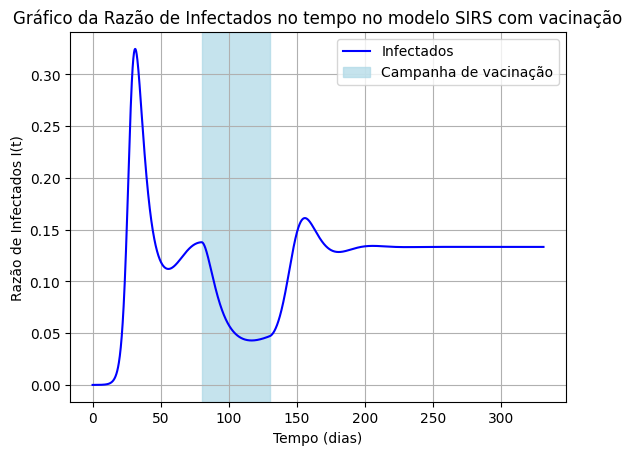

In [37]:
ixt(arquivo_h5['sim_0'])  # Exemplo de uso da função com a primeira simulação

Gráficos de (S, I, R) x t com campanha de vacinação:

In [40]:
def sirxt(grupo_simulacao, nome_arquivo_saida=None):
    # 1. Extrai os dados e parâmetros dos datasets
    tempo = grupo_simulacao['tempo'][:]
    I = grupo_simulacao['I'][:]
    S = grupo_simulacao['S'][:]
    R = grupo_simulacao['R'][:]
    params = grupo_simulacao.attrs
    r0 = params.get('r0', 'N/A')
    delta = params.get('delta', 'N/A')
    n = params.get('n', 'N/A')
    mu = params.get('mu', 'N/A')
    vac_num = params.get('vac_num', 'N/A')
    a = params.get('a', 'N/A')
    t0 = params.get('t0', 'N/A')
    tf = t0 + vac_num/a
    t_final = params.get('t_final', tempo[-1])
    motivo_parada = params.get('motivo_parada', 'N/A')
    prob_ext = params.get('prob_ext', 'N/A')
    # 2. Plotando os gráficos:
    plt.plot(tempo, I, label='Infectados', color='blue')
    plt.plot(tempo, S, label='Suscetíveis', color='red')
    plt.plot(tempo, R, label='Recuperados', color='orange')
    plt.axvspan(t0, tf, color='lightblue', alpha=0.7, label="Campanha de vacinação")
    plt.title('Gráfico da Razão de Infectados no tempo no modelo SIRS com vacinação')
    plt.grid()
    plt.xlabel('Tempo (dias)')
    plt.ylabel('Razão de Infectados I(t)')
    plt.legend(loc = 'upper right')
    print(f'r0 = {r0}, mu = {mu}, a = {a}, n = {n}, delta = {delta}, vac_num = {vac_num}, t0 = {t0}, Tempo até atingir o estado estacionário = {t_final}, Motivo da parada = {motivo_parada}, Probabilidade de Extinção = {prob_ext}')

In [ ]:
print(simulacoes_disponiveis)  # Exibe as simulações disponíveis

r0 = 3.0, mu = 0.2, a = 0.08, n = 100000.0, delta = 0.05, vac_num = 1.0, t0 = 80.0, Tempo até atingir o estado estacionário = 86.10430521526077, Motivo da parada = N/A, Probabilidade de Extinção = 0.0


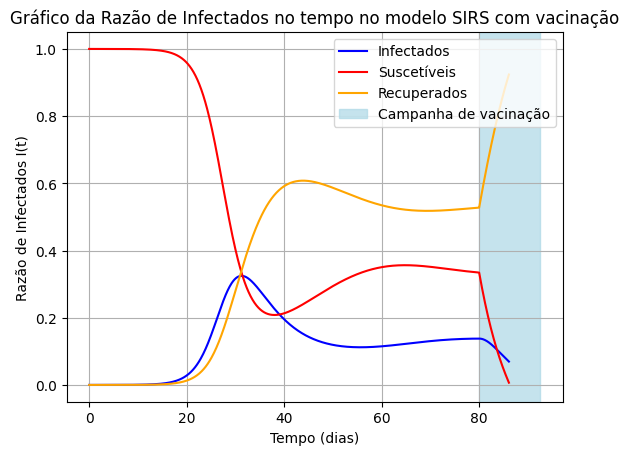

In [44]:
sirxt(arquivo_h5['sim_3']) 

Mapa de Calor: Probabilidade de Extinção em função de R0 e do número de vacinas para um conjunto fixo dos demais parâmetros

In [54]:
def r0xvac_num(arquivo, nome_arquivo_saida=None):
    dados = []
    for grupo_simulacao in arquivo.values():
        # 1. Extrai os dados e parâmetros dos datasets
        params = grupo_simulacao.attrs
        r0 = params.get('r0', 'N/A')
        prob_ext = params.get('prob_ext', 'N/A')
        vac_num = params.get('vac_num', 'N/A')
        # 2. Armazena os dados em uma lista de dicionários
        dados_simulacao = {
            'Basic Reprodution Number': r0,
            'Vaccines Number (Normalized)': vac_num,
            'Extinction Probability': prob_ext
        }
        dados.append(dados_simulacao)
    dados = pd.DataFrame(dados)

    x = dados['Basic Reprodution Number']
    y = dados['Vaccines Number (Normalized)']
    z = dados['Extinction Probability']
    x_unique = np.sort(x.unique())
    y_unique = np.sort(y.unique())
    # Criando uma matriz de zeros com dimensões baseadas em x e y
    Z = np.zeros((len(y_unique), len(x_unique)))
    # Preencher a matriz Z com os valores correspondentes
    for i, xi in enumerate(x_unique):
        for j, yj in enumerate(y_unique):
            mask = (x == xi) & (y == yj)
            if mask.any():
                Z[j, i] = dados.loc[mask, 'Extinction Probability'].mean()
    print(Z)
                # Criar o gráfico de mapa de calor
    plt.figure(figsize=(10, 6))
    plt.imshow(Z, aspect='auto', origin='lower', cmap='hot',
            extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)

    # Cor da barra de cor
    cbar = plt.colorbar(label="Extinction Probability")
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
    cbar.set_label("Extinction Probability", color='black')

    # Eixos e título em preto
    plt.xlabel('Basic Reprodution Number', color='black')
    plt.ylabel('Vaccines Number (Normalized)', color='black')
    plt.title("Extinction Probability: Basic Reprodution Number x Vaccines Number (Normalized)", color='black')

    # Ticks em preto
    plt.tick_params(axis='both', colors='black')
    plt.grid(False)
    plt.show()

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.18613157 0.         0.         ... 0.         0.         0.        ]
 [0.37085385 0.         0.         ... 0.         0.         0.        ]
 ...
 [0.9979892  0.99734478 0.99646219 ... 0.         0.         0.        ]
 [0.9979892  0.99734478 0.99646219 ... 0.         0.         0.        ]
 [0.9979892  0.99734478 0.99646219 ... 0.         0.         0.        ]]


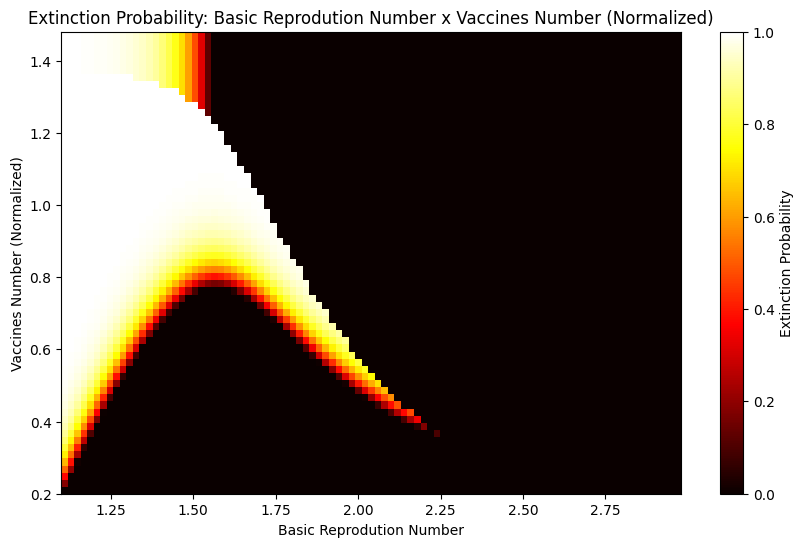

In [65]:
r0xvac_num(arquivo_h5)